In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
import random
from pathlib import Path
from datetime import datetime


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Размер train датасета: 112800
Размер test датасета: 18800
Количество классов: 47
Форма изображения: torch.Size([1, 28, 28])
Train size: 90240
Val size: 22560
Test size: 18800
Train batches: 705
Val batches: 177
Test batches: 147

Sanity-check:
Форма батча: torch.Size([128, 1, 28, 28])
Форма меток: torch.Size([128])
Минимальное значение: -1.000
Максимальное значение: 1.000
Уникальные метки: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  9, 10, 12, 13, 14, 15, 16, 17, 18, 19,
        20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
        38, 39, 40, 41, 42, 43, 44, 45, 46])
Тип данных: torch.float32


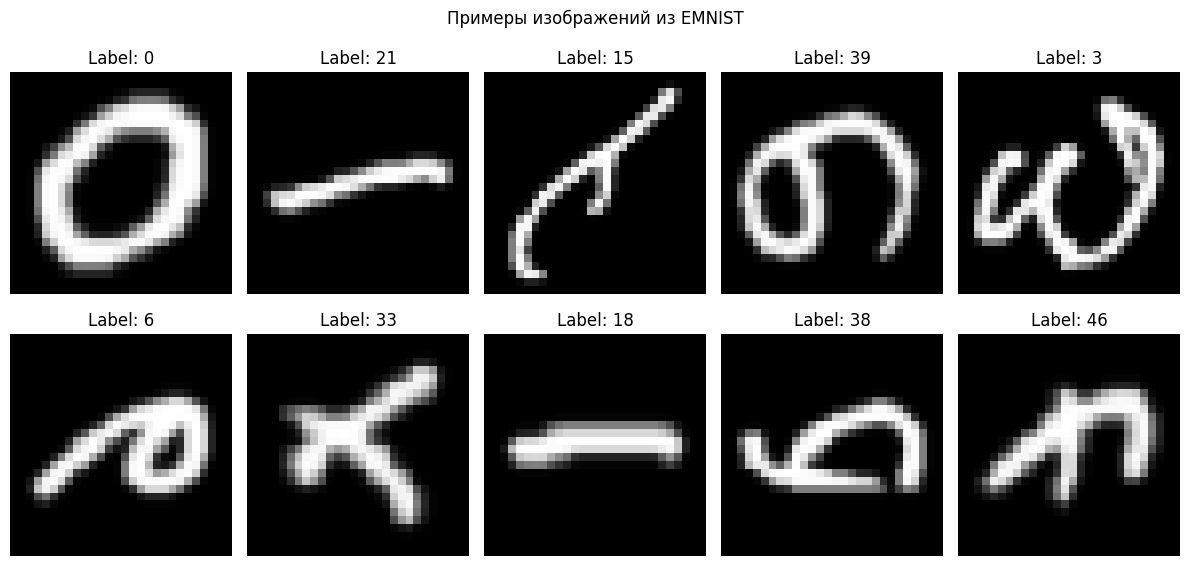

In [2]:
# Трансформации для нормализации данных
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.EMNIST(
    root='./data',
    split='balanced',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.EMNIST(
    root='./data',
    split='balanced',
    train=False,
    download=True,
    transform=transform
)

print(f"Размер train датасета: {len(train_dataset)}")
print(f"Размер test датасета: {len(test_dataset)}")
print(f"Количество классов: {len(train_dataset.classes)}")
print(f"Форма изображения: {train_dataset[0][0].shape}")

# Разбиение train на train/val (80/20)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_indices, val_indices = random_split(
    range(len(train_dataset)),
    [train_size, val_size]
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

print(f"Train size: {len(train_subset)}")
print(f"Val size: {len(val_subset)}")
print(f"Test size: {len(test_dataset)}")

# Создаем DataLoader
batch_size = 128
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Sanity-check одного батча
x, y = next(iter(train_loader))
print(f"\nSanity-check:")
print(f"Форма батча: {x.shape}")
print(f"Форма меток: {y.shape}")
print(f"Минимальное значение: {x.min():.3f}")
print(f"Максимальное значение: {x.max():.3f}")
print(f"Уникальные метки: {torch.unique(y)}")
print(f"Тип данных: {x.dtype}")

# Визуализация нескольких изображений
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = x[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {y[i].item()}')
    ax.axis('off')
plt.suptitle('Примеры изображений из EMNIST')
plt.tight_layout()
plt.savefig('artifacts/figures/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=[512, 256, 128], dropout=0.0, use_batchnorm=False, num_classes=47):
        super(MLP, self).__init__()

        layers = []
        input_size = 28 * 28

        # Строим скрытые слои
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))

            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))

            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            input_size = hidden_size

        # Выходной слой
        layers.append(nn.Linear(input_size, num_classes))

        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

    def get_summary(self):
        return f"MLP_{self.layers}"


def train_epoch(model, loader, criterion, optimizer, device):
    """
    Обучение на одной эпохе
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """
    Оценка модели на валидационной/тестовой выборке
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs, device, early_stopping_patience=None, experiment_id=None):
    """
    Полный цикл обучения модели с валидацией
    """
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0
    best_epoch = 0

    for epoch in range(num_epochs):
        # Обучение
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Эпоха {epoch + 1}/{num_epochs}:')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

        # Проверяем улучшение
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            best_epoch = epoch + 1
            print(f'  --> Новая лучшая модель! (Val Acc: {val_acc:.2f}%)')
        else:
            patience_counter += 1
            print(f'  patience: {patience_counter}/{early_stopping_patience if early_stopping_patience else "∞"}')

        # Early stopping
        if early_stopping_patience and patience_counter >= early_stopping_patience:
            print(f"\nРанняя остановка на эпохе {epoch + 1}")
            break

        print()

    # Загружаем лучшую модель
    model.load_state_dict(best_model_state)
    print(f"Обучение завершено. Лучшая модель на эпохе {best_epoch} с Val Acc: {best_val_acc:.2f}%")

    return history, best_val_acc, val_loss

In [4]:
def plot_training_history(history, title, save_path=None):
    """
    Визуализация истории обучения
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # График потерь
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()
    axes[0].grid(True)

    # График точности
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['val_acc'], label='Val Acc', marker='o')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()


def save_experiment_result(results_df, experiment_id, config, history, best_val_acc, best_val_loss):
    """
    Сохраняет результат эксперимента в DataFrame
    """
    model_summary = f"layers={config['hidden_sizes']}, dropout={config['dropout']}, batchnorm={config['use_batchnorm']}"

    new_row = {
        'experiment_id': experiment_id,
        'dataset': 'EMNIST',
        'seed': 42,
        'model_summary': model_summary,
        'optimizer': config['optimizer'],
        'lr': config['lr'],
        'momentum': config.get('momentum', 0),
        'weight_decay': config.get('weight_decay', 0),
        'epochs_trained': len(history['train_loss']),
        'best_val_accuracy': round(best_val_acc, 4),
        'best_val_loss': round(best_val_loss, 4)
    }

    return pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)

ЭКСПЕРИМЕНТ E1: Base MLP (без Dropout и BatchNorm)
Модель: MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=47, bias=True)
  )
)
Параметров: 572207
Эпоха 1/15:
  Train Loss: 1.2117, Train Acc: 64.38%
  Val Loss: 0.7889, Val Acc: 74.47%
  --> Новая лучшая модель! (Val Acc: 74.47%)

Эпоха 2/15:
  Train Loss: 0.6480, Train Acc: 79.04%
  Val Loss: 0.6039, Val Acc: 80.41%
  --> Новая лучшая модель! (Val Acc: 80.41%)

Эпоха 3/15:
  Train Loss: 0.5399, Train Acc: 81.84%
  Val Loss: 0.5817, Val Acc: 80.58%
  --> Новая лучшая модель! (Val Acc: 80.58%)

Эпоха 4/15:
  Train Loss: 0.4782, Train Acc: 83.50%
  Val Loss: 0.5209, Val Acc: 82.42%
  --> Новая лучшая модель! (Val Acc: 82.42%)

Эпоха 5/15

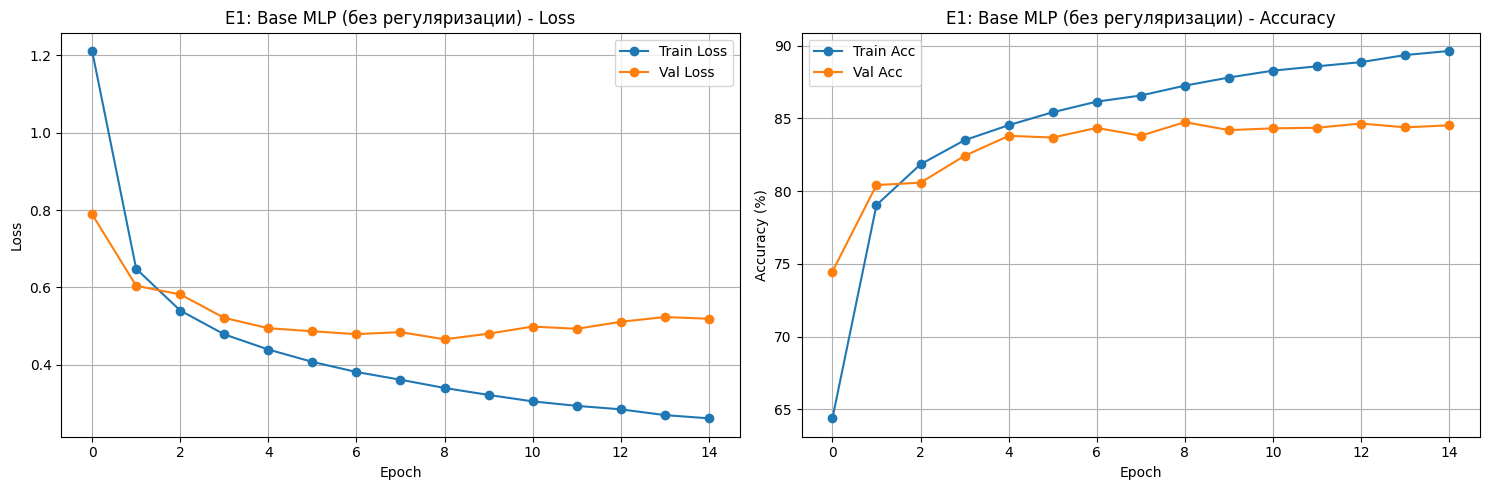

In [5]:
print("ЭКСПЕРИМЕНТ E1: Base MLP (без Dropout и BatchNorm)")

# Конфигурация E1
config_e1 = {
    'hidden_sizes': [512, 256, 128],
    'dropout': 0.0,
    'use_batchnorm': False,
    'optimizer': 'Adam',
    'lr': 0.001,
    'weight_decay': 0,
    'num_epochs': 15,
    'early_stopping': None
}

model_e1 = MLP(
    hidden_sizes=config_e1['hidden_sizes'],
    dropout=config_e1['dropout'],
    use_batchnorm=config_e1['use_batchnorm']
).to(device)

print(f"Модель: {model_e1}")
print(f"Параметров: {sum(p.numel() for p in model_e1.parameters())}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e1.parameters(), lr=config_e1['lr'])

# Обучение
history_e1, best_val_acc_e1, best_val_loss_e1 = train_model(
    model=model_e1,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=config_e1['num_epochs'],
    device=device,
    experiment_id='E1'
)

# Визуализация
plot_training_history(
    history_e1,
    'E1: Base MLP (без регуляризации)',
    save_path='artifacts/figures/curves_e1.png'
)

results_df = save_experiment_result(
    pd.DataFrame(), 'E1', config_e1, history_e1, best_val_acc_e1, best_val_loss_e1
)

histories = {'E1': history_e1}

ЭКСПЕРИМЕНТ E2: MLP с Dropout
Модель с Dropout=0.3
Параметров: 572207
Эпоха 1/15:
  Train Loss: 1.6338, Train Acc: 52.42%
  Val Loss: 0.8363, Val Acc: 74.22%
  --> Новая лучшая модель! (Val Acc: 74.22%)

Эпоха 2/15:
  Train Loss: 0.9852, Train Acc: 69.34%
  Val Loss: 0.6913, Val Acc: 78.06%
  --> Новая лучшая модель! (Val Acc: 78.06%)

Эпоха 3/15:
  Train Loss: 0.8581, Train Acc: 72.76%
  Val Loss: 0.6404, Val Acc: 79.33%
  --> Новая лучшая модель! (Val Acc: 79.33%)

Эпоха 4/15:
  Train Loss: 0.7935, Train Acc: 74.62%
  Val Loss: 0.5879, Val Acc: 80.57%
  --> Новая лучшая модель! (Val Acc: 80.57%)

Эпоха 5/15:
  Train Loss: 0.7504, Train Acc: 75.96%
  Val Loss: 0.5521, Val Acc: 81.71%
  --> Новая лучшая модель! (Val Acc: 81.71%)

Эпоха 6/15:
  Train Loss: 0.7152, Train Acc: 76.73%
  Val Loss: 0.5356, Val Acc: 82.01%
  --> Новая лучшая модель! (Val Acc: 82.01%)

Эпоха 7/15:
  Train Loss: 0.6984, Train Acc: 77.23%
  Val Loss: 0.5294, Val Acc: 81.88%
  patience: 1/∞

Эпоха 8/15:
  Train L

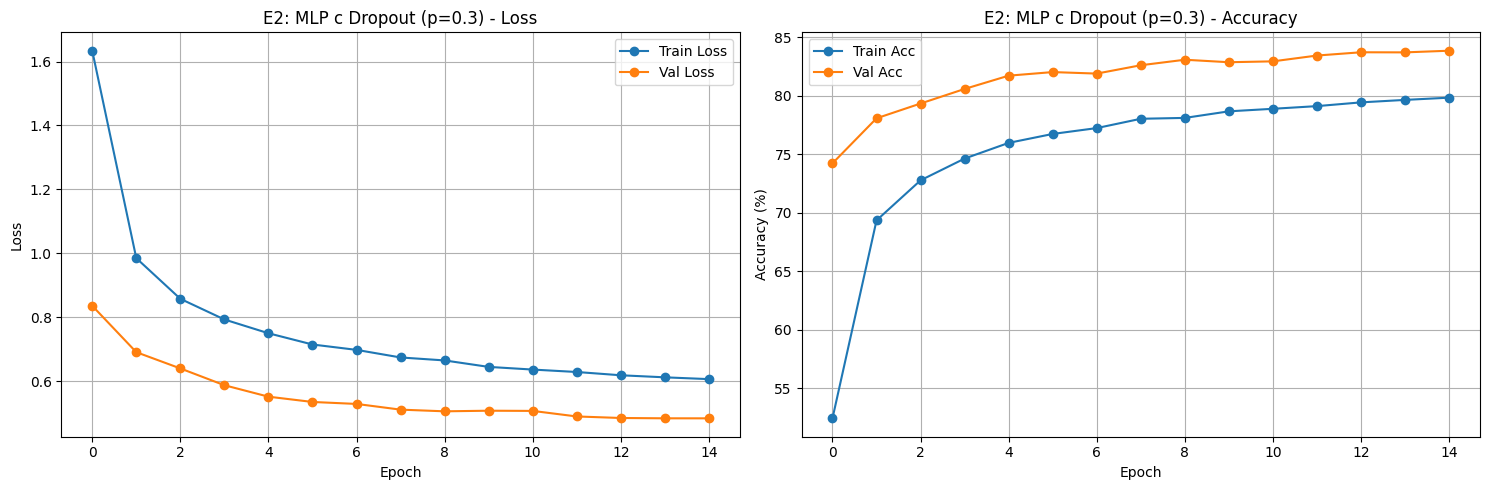

In [6]:
print("ЭКСПЕРИМЕНТ E2: MLP с Dropout")

# Конфигурация E2
config_e2 = {
    'hidden_sizes': [512, 256, 128],
    'dropout': 0.3,
    'use_batchnorm': False,
    'optimizer': 'Adam',
    'lr': 0.001,
    'weight_decay': 0,
    'num_epochs': 15,
    'early_stopping': None
}

model_e2 = MLP(
    hidden_sizes=config_e2['hidden_sizes'],
    dropout=config_e2['dropout'],
    use_batchnorm=config_e2['use_batchnorm']
).to(device)

print(f"Модель с Dropout={config_e2['dropout']}")
print(f"Параметров: {sum(p.numel() for p in model_e2.parameters())}")

optimizer = optim.Adam(model_e2.parameters(), lr=config_e2['lr'])

# Обучение
history_e2, best_val_acc_e2, best_val_loss_e2 = train_model(
    model=model_e2,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=config_e2['num_epochs'],
    device=device,
    experiment_id='E2'
)

# Визуализация
plot_training_history(
    history_e2,
    'E2: MLP с Dropout (p=0.3)',
    save_path='artifacts/figures/curves_e2.png'
)

results_df = save_experiment_result(
    results_df, 'E2', config_e2, history_e2, best_val_acc_e2, best_val_loss_e2
)

histories['E2'] = history_e2

ЭКСПЕРИМЕНТ E3: MLP с BatchNorm
Модель с BatchNorm
Параметров: 573999
Эпоха 1/15:
  Train Loss: 0.8974, Train Acc: 74.83%
  Val Loss: 0.6021, Val Acc: 80.43%
  --> Новая лучшая модель! (Val Acc: 80.43%)

Эпоха 2/15:
  Train Loss: 0.4862, Train Acc: 83.44%
  Val Loss: 0.4913, Val Acc: 83.36%
  --> Новая лучшая модель! (Val Acc: 83.36%)

Эпоха 3/15:
  Train Loss: 0.4112, Train Acc: 85.47%
  Val Loss: 0.4755, Val Acc: 84.07%
  --> Новая лучшая модель! (Val Acc: 84.07%)

Эпоха 4/15:
  Train Loss: 0.3629, Train Acc: 86.80%
  Val Loss: 0.4424, Val Acc: 84.84%
  --> Новая лучшая модель! (Val Acc: 84.84%)

Эпоха 5/15:
  Train Loss: 0.3298, Train Acc: 87.88%
  Val Loss: 0.4421, Val Acc: 84.81%
  patience: 1/∞

Эпоха 6/15:
  Train Loss: 0.3037, Train Acc: 88.54%
  Val Loss: 0.4445, Val Acc: 85.07%
  --> Новая лучшая модель! (Val Acc: 85.07%)

Эпоха 7/15:
  Train Loss: 0.2796, Train Acc: 89.30%
  Val Loss: 0.4410, Val Acc: 85.31%
  --> Новая лучшая модель! (Val Acc: 85.31%)

Эпоха 8/15:
  Train L

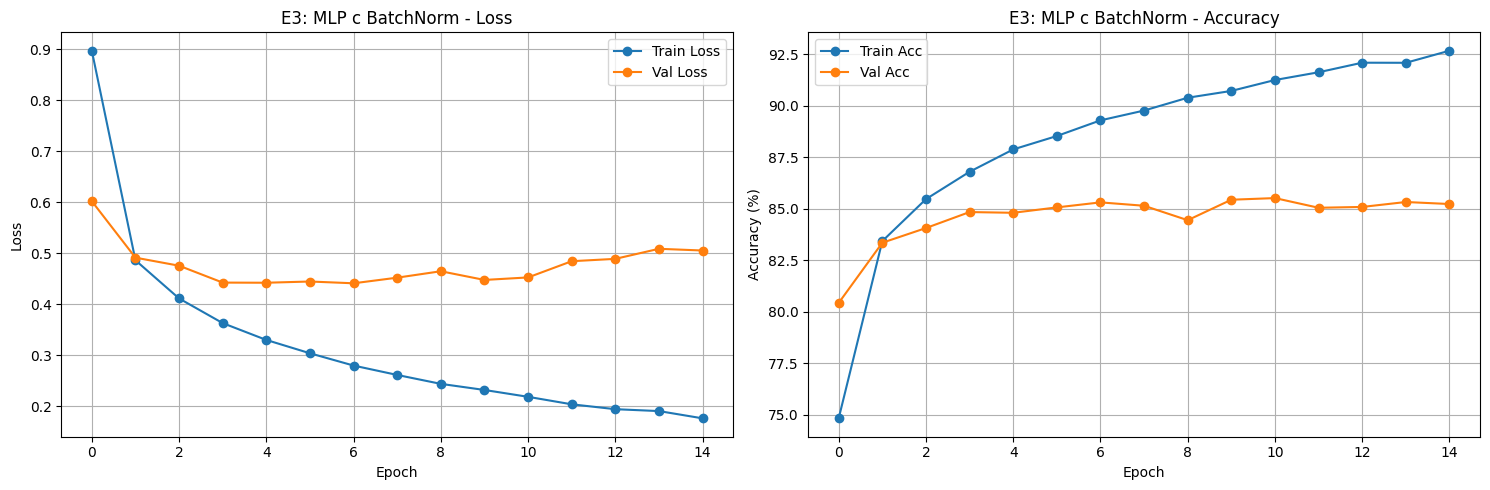

In [7]:
print("ЭКСПЕРИМЕНТ E3: MLP с BatchNorm")

# Конфигурация E3
config_e3 = {
    'hidden_sizes': [512, 256, 128],
    'dropout': 0.0,
    'use_batchnorm': True,
    'optimizer': 'Adam',
    'lr': 0.001,
    'weight_decay': 0,
    'num_epochs': 15,
    'early_stopping': None
}

# Создаем модель
model_e3 = MLP(
    hidden_sizes=config_e3['hidden_sizes'],
    dropout=config_e3['dropout'],
    use_batchnorm=config_e3['use_batchnorm']
).to(device)

print(f"Модель с BatchNorm")
print(f"Параметров: {sum(p.numel() for p in model_e3.parameters())}")

optimizer = optim.Adam(model_e3.parameters(), lr=config_e3['lr'])

# Обучение
history_e3, best_val_acc_e3, best_val_loss_e3 = train_model(
    model=model_e3,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=config_e3['num_epochs'],
    device=device,
    experiment_id='E3'
)

# Визуализация
plot_training_history(
    history_e3,
    'E3: MLP с BatchNorm',
    save_path='artifacts/figures/curves_e3.png'
)

results_df = save_experiment_result(
    results_df, 'E3', config_e3, history_e3, best_val_acc_e3, best_val_loss_e3
)

histories['E3'] = history_e3

    Experiment  Best Val Acc  Best Val Loss
  E2 (Dropout)     83.838652       0.484373
E3 (BatchNorm)     85.523050       0.505327

Лучшая модель: E3 с точностью 85.52%


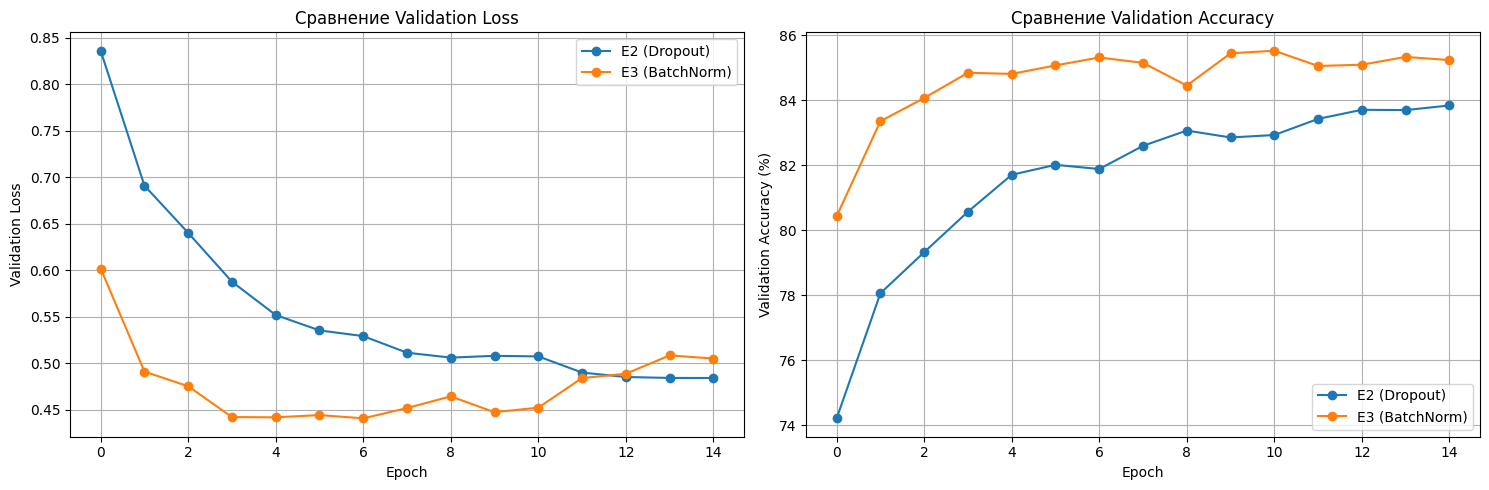

In [8]:
comparison = pd.DataFrame({
    'Experiment': ['E2 (Dropout)', 'E3 (BatchNorm)'],
    'Best Val Acc': [best_val_acc_e2, best_val_acc_e3],
    'Best Val Loss': [best_val_loss_e2, best_val_loss_e3]
})
print(comparison.to_string(index=False))

best_exp = max([('E2', best_val_acc_e2), ('E3', best_val_acc_e3)], key=lambda x: x[1])
print(f"\nЛучшая модель: {best_exp[0]} с точностью {best_exp[1]:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(histories['E2']['val_loss'], label='E2 (Dropout)', marker='o')
axes[0].plot(histories['E3']['val_loss'], label='E3 (BatchNorm)', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Сравнение Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(histories['E2']['val_acc'], label='E2 (Dropout)', marker='o')
axes[1].plot(histories['E3']['val_acc'], label='E3 (BatchNorm)', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy (%)')
axes[1].set_title('Сравнение Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/comparison_e1_e3.png', dpi=150, bbox_inches='tight')
plt.show()

ЭКСПЕРИМЕНТ E4: Лучшая модель с Early Stopping
Модель с Dropout=0.0 и Early Stopping (patience=5)
Параметров: 573999
Эпоха 1/30:
  Train Loss: 0.9027, Train Acc: 74.62%
  Val Loss: 0.5458, Val Acc: 82.02%
  --> Новая лучшая модель! (Val Acc: 82.02%)

Эпоха 2/30:
  Train Loss: 0.4922, Train Acc: 83.30%
  Val Loss: 0.4812, Val Acc: 83.91%
  --> Новая лучшая модель! (Val Acc: 83.91%)

Эпоха 3/30:
  Train Loss: 0.4105, Train Acc: 85.60%
  Val Loss: 0.4639, Val Acc: 84.09%
  --> Новая лучшая модель! (Val Acc: 84.09%)

Эпоха 4/30:
  Train Loss: 0.3637, Train Acc: 86.77%
  Val Loss: 0.4526, Val Acc: 84.61%
  --> Новая лучшая модель! (Val Acc: 84.61%)

Эпоха 5/30:
  Train Loss: 0.3272, Train Acc: 87.88%
  Val Loss: 0.4359, Val Acc: 85.22%
  --> Новая лучшая модель! (Val Acc: 85.22%)

Эпоха 6/30:
  Train Loss: 0.3031, Train Acc: 88.47%
  Val Loss: 0.4356, Val Acc: 85.57%
  --> Новая лучшая модель! (Val Acc: 85.57%)

Эпоха 7/30:
  Train Loss: 0.2804, Train Acc: 89.25%
  Val Loss: 0.4389, Val Acc

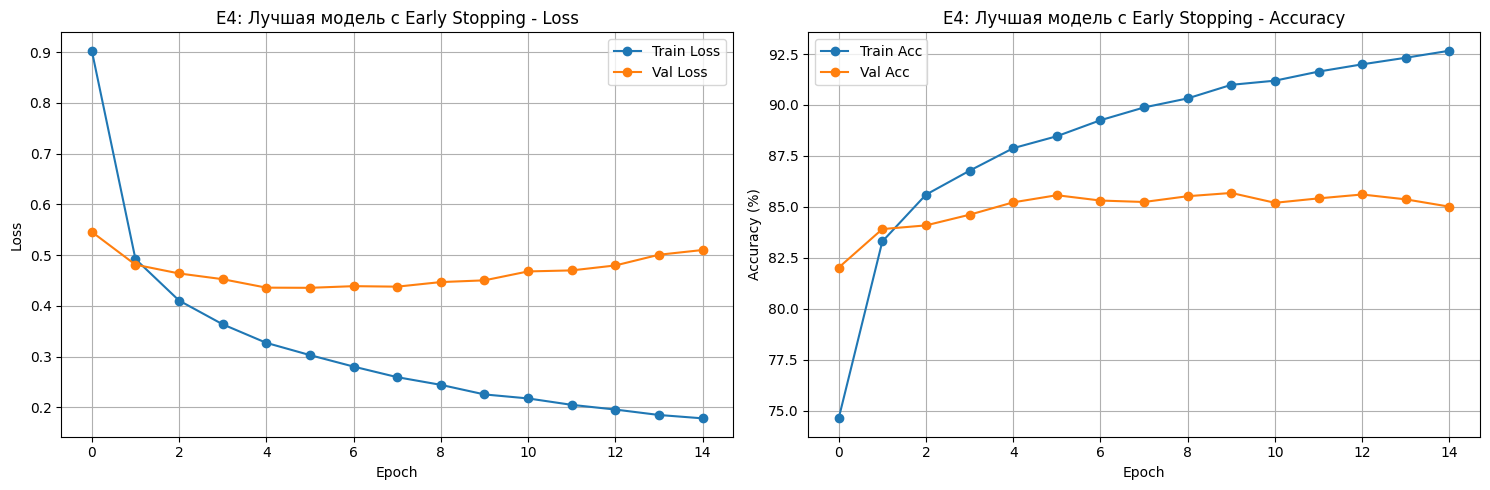


Лучшая модель сохранена в artifacts/best_model.pt


In [9]:
print("ЭКСПЕРИМЕНТ E4: Лучшая модель с Early Stopping")

config_e4 = {
    'hidden_sizes': [512, 256, 128],
    'dropout': 0.0,
    'use_batchnorm': True,
    'optimizer': 'Adam',
    'lr': 0.001,
    'weight_decay': 0,
    'num_epochs': 30,  # больше эпох для early stopping
    'early_stopping': 5  # patience=5
}

# Создаем модель
model_e4 = MLP(
    hidden_sizes=config_e4['hidden_sizes'],
    dropout=config_e4['dropout'],
    use_batchnorm=config_e4['use_batchnorm']
).to(device)

print(f"Модель с Dropout={config_e4['dropout']} и Early Stopping (patience=5)")
print(f"Параметров: {sum(p.numel() for p in model_e4.parameters())}")

# Оптимизатор и функция потерь
optimizer = optim.Adam(model_e4.parameters(), lr=config_e4['lr'])

# Обучение с early stopping
history_e4, best_val_acc_e4, best_val_loss_e4 = train_model(
    model=model_e4,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=config_e4['num_epochs'],
    device=device,
    early_stopping_patience=config_e4['early_stopping'],
    experiment_id='E4'
)

# Визуализация
plot_training_history(
    history_e4,
    'E4: Лучшая модель с Early Stopping',
    save_path='artifacts/figures/curves_best.png'
)

# Сохраняем результат
results_df = save_experiment_result(
    results_df, 'E4', config_e4, history_e4, best_val_acc_e4, best_val_loss_e4
)

# Сохраняем лучшую модель
torch.save(model_e4.state_dict(), 'artifacts/best_model.pt')
print("\nЛучшая модель сохранена в artifacts/best_model.pt")

In [10]:
print("ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ (E4) НА ТЕСТОВОЙ ВЫБОРКЕ")

# Оценка на тесте
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Конфиг лучшей модели
best_config = {
    'hidden_sizes': config_e4['hidden_sizes'],
    'dropout': config_e4['dropout'],
    'use_batchnorm': config_e4['use_batchnorm'],
    'num_classes': 47,
    'optimizer': config_e4['optimizer'],
    'lr': config_e4['lr'],
    'weight_decay': config_e4['weight_decay'],
    'early_stopping_patience': config_e4['early_stopping'],
    'batch_size': batch_size,
    'dataset': 'EMNIST',
    'seed': 42,
    'test_accuracy': round(test_acc, 4),
    'test_loss': round(test_loss, 4),
    'best_val_accuracy': round(best_val_acc_e4, 4)
}

with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)

print("\nКонфиг лучшей модели сохранен в artifacts/best_config.json")

ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ (E4) НА ТЕСТОВОЙ ВЫБОРКЕ
Test Loss: 0.5354
Test Accuracy: 84.80%

Конфиг лучшей модели сохранен в artifacts/best_config.json


In [11]:
print("ЭКСПЕРИМЕНТ O1: LR слишком большой (1e-1)")

# Конфигурация O1
config_o1 = {
    'hidden_sizes': [512, 256, 128],
    'dropout': 0.0,
    'use_batchnorm': False,
    'optimizer': 'Adam',
    'lr': 0.1,
    'weight_decay': 0,
    'num_epochs': 8,
    'early_stopping': None
}

# Создаем модель
model_o1 = MLP(
    hidden_sizes=config_o1['hidden_sizes'],
    dropout=config_o1['dropout'],
    use_batchnorm=config_o1['use_batchnorm']
).to(device)

print(f"LR = {config_o1['lr']} (слишком большой)")

optimizer = optim.Adam(model_o1.parameters(), lr=config_o1['lr'])

# Обучение
history_o1, best_val_acc_o1, best_val_loss_o1 = train_model(
    model=model_o1,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=config_o1['num_epochs'],
    device=device,
    experiment_id='O1'
)

# Сохраняем результат
results_df = save_experiment_result(
    results_df, 'O1', config_o1, history_o1, best_val_acc_o1, best_val_loss_o1
)

ЭКСПЕРИМЕНТ O1: LR слишком большой (1e-1)
LR = 0.1 (слишком большой)
Эпоха 1/8:
  Train Loss: 30.6051, Train Acc: 2.17%
  Val Loss: 3.8642, Val Acc: 2.27%
  --> Новая лучшая модель! (Val Acc: 2.27%)

Эпоха 2/8:
  Train Loss: 3.8643, Train Acc: 2.07%
  Val Loss: 3.8603, Val Acc: 2.11%
  patience: 1/∞

Эпоха 3/8:
  Train Loss: 3.8645, Train Acc: 2.09%
  Val Loss: 3.8638, Val Acc: 2.01%
  patience: 2/∞

Эпоха 4/8:
  Train Loss: 3.8645, Train Acc: 2.21%
  Val Loss: 3.8672, Val Acc: 2.07%
  patience: 3/∞

Эпоха 5/8:
  Train Loss: 3.8641, Train Acc: 2.15%
  Val Loss: 3.8642, Val Acc: 2.00%
  patience: 4/∞

Эпоха 6/8:
  Train Loss: 3.8641, Train Acc: 2.18%
  Val Loss: 3.8692, Val Acc: 2.04%
  patience: 5/∞

Эпоха 7/8:
  Train Loss: 3.8659, Train Acc: 2.06%
  Val Loss: 3.8706, Val Acc: 2.04%
  patience: 6/∞

Эпоха 8/8:
  Train Loss: 3.8636, Train Acc: 2.15%
  Val Loss: 3.8638, Val Acc: 2.03%
  patience: 7/∞

Обучение завершено. Лучшая модель на эпохе 1 с Val Acc: 2.27%


In [12]:
print("ЭКСПЕРИМЕНТ O2: LR слишком маленький (1e-5)")

# Конфигурация O2
config_o2 = {
    'hidden_sizes': [512, 256, 128],
    'dropout': 0.0,
    'use_batchnorm': False,
    'optimizer': 'Adam',
    'lr': 1e-5,
    'weight_decay': 0,
    'num_epochs': 8,
    'early_stopping': None
}

# Создаем модель
model_o2 = MLP(
    hidden_sizes=config_o2['hidden_sizes'],
    dropout=config_o2['dropout'],
    use_batchnorm=config_o2['use_batchnorm']
).to(device)

print(f"LR = {config_o2['lr']} (слишком маленький)")

optimizer = optim.Adam(model_o2.parameters(), lr=config_o2['lr'])

# Обучение
history_o2, best_val_acc_o2, best_val_loss_o2 = train_model(
    model=model_o2,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=config_o2['num_epochs'],
    device=device,
    experiment_id='O2'
)

# Сохраняем результат
results_df = save_experiment_result(
    results_df, 'O2', config_o2, history_o2, best_val_acc_o2, best_val_loss_o2
)

ЭКСПЕРИМЕНТ O2: LR слишком маленький (1e-5)
LR = 1e-05 (слишком маленький)
Эпоха 1/8:
  Train Loss: 3.6561, Train Acc: 12.70%
  Val Loss: 3.2771, Val Acc: 25.12%
  --> Новая лучшая модель! (Val Acc: 25.12%)

Эпоха 2/8:
  Train Loss: 2.7761, Train Acc: 35.94%
  Val Loss: 2.3687, Val Acc: 43.07%
  --> Новая лучшая модель! (Val Acc: 43.07%)

Эпоха 3/8:
  Train Loss: 2.1296, Train Acc: 46.89%
  Val Loss: 1.9545, Val Acc: 49.51%
  --> Новая лучшая модель! (Val Acc: 49.51%)

Эпоха 4/8:
  Train Loss: 1.8368, Train Acc: 51.70%
  Val Loss: 1.7454, Val Acc: 53.43%
  --> Новая лучшая модель! (Val Acc: 53.43%)

Эпоха 5/8:
  Train Loss: 1.6734, Train Acc: 54.80%
  Val Loss: 1.6183, Val Acc: 55.88%
  --> Новая лучшая модель! (Val Acc: 55.88%)

Эпоха 6/8:
  Train Loss: 1.5671, Train Acc: 57.04%
  Val Loss: 1.5288, Val Acc: 57.93%
  --> Новая лучшая модель! (Val Acc: 57.93%)

Эпоха 7/8:
  Train Loss: 1.4908, Train Acc: 58.69%
  Val Loss: 1.4665, Val Acc: 59.28%
  --> Новая лучшая модель! (Val Acc: 59.

In [13]:
print("ЭКСПЕРИМЕНТ O3: SGD + momentum + weight decay")

# Конфигурация O3
config_o3 = {
    'hidden_sizes': [512, 256, 128],
    'dropout': 0.0,
    'use_batchnorm': False,
    'optimizer': 'SGD',
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'num_epochs': 15,
    'early_stopping': None
}

# Создаем модель
model_o3 = MLP(
    hidden_sizes=config_o3['hidden_sizes'],
    dropout=config_o3['dropout'],
    use_batchnorm=config_o3['use_batchnorm']
).to(device)

print(
    f"Оптимизатор: SGD, lr={config_o3['lr']}, momentum={config_o3['momentum']}, weight_decay={config_o3['weight_decay']}")

optimizer = optim.SGD(
    model_o3.parameters(),
    lr=config_o3['lr'],
    momentum=config_o3['momentum'],
    weight_decay=config_o3['weight_decay']
)

# Обучение
history_o3, best_val_acc_o3, best_val_loss_o3 = train_model(
    model=model_o3,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=config_o3['num_epochs'],
    device=device,
    experiment_id='O3'
)

# Сохраняем результат
results_df = save_experiment_result(
    results_df, 'O3', config_o3, history_o3, best_val_acc_o3, best_val_loss_o3
)

ЭКСПЕРИМЕНТ O3: SGD + momentum + weight decay
Оптимизатор: SGD, lr=0.01, momentum=0.9, weight_decay=0.0001
Эпоха 1/15:
  Train Loss: 1.8629, Train Acc: 49.05%
  Val Loss: 1.0377, Val Acc: 68.85%
  --> Новая лучшая модель! (Val Acc: 68.85%)

Эпоха 2/15:
  Train Loss: 0.8358, Train Acc: 74.06%
  Val Loss: 0.7121, Val Acc: 77.87%
  --> Новая лучшая модель! (Val Acc: 77.87%)

Эпоха 3/15:
  Train Loss: 0.6459, Train Acc: 79.10%
  Val Loss: 0.6143, Val Acc: 80.05%
  --> Новая лучшая модель! (Val Acc: 80.05%)

Эпоха 4/15:
  Train Loss: 0.5610, Train Acc: 81.53%
  Val Loss: 0.5707, Val Acc: 81.21%
  --> Новая лучшая модель! (Val Acc: 81.21%)

Эпоха 5/15:
  Train Loss: 0.5050, Train Acc: 82.95%
  Val Loss: 0.5359, Val Acc: 82.05%
  --> Новая лучшая модель! (Val Acc: 82.05%)

Эпоха 6/15:
  Train Loss: 0.4659, Train Acc: 84.10%
  Val Loss: 0.5274, Val Acc: 81.89%
  patience: 1/∞

Эпоха 7/15:
  Train Loss: 0.4303, Train Acc: 85.03%
  Val Loss: 0.4827, Val Acc: 83.92%
  --> Новая лучшая модель! (Va

ВИЗУАЛИЗАЦИЯ ЭКСТРЕМАЛЬНЫХ LR (O1 и O2)


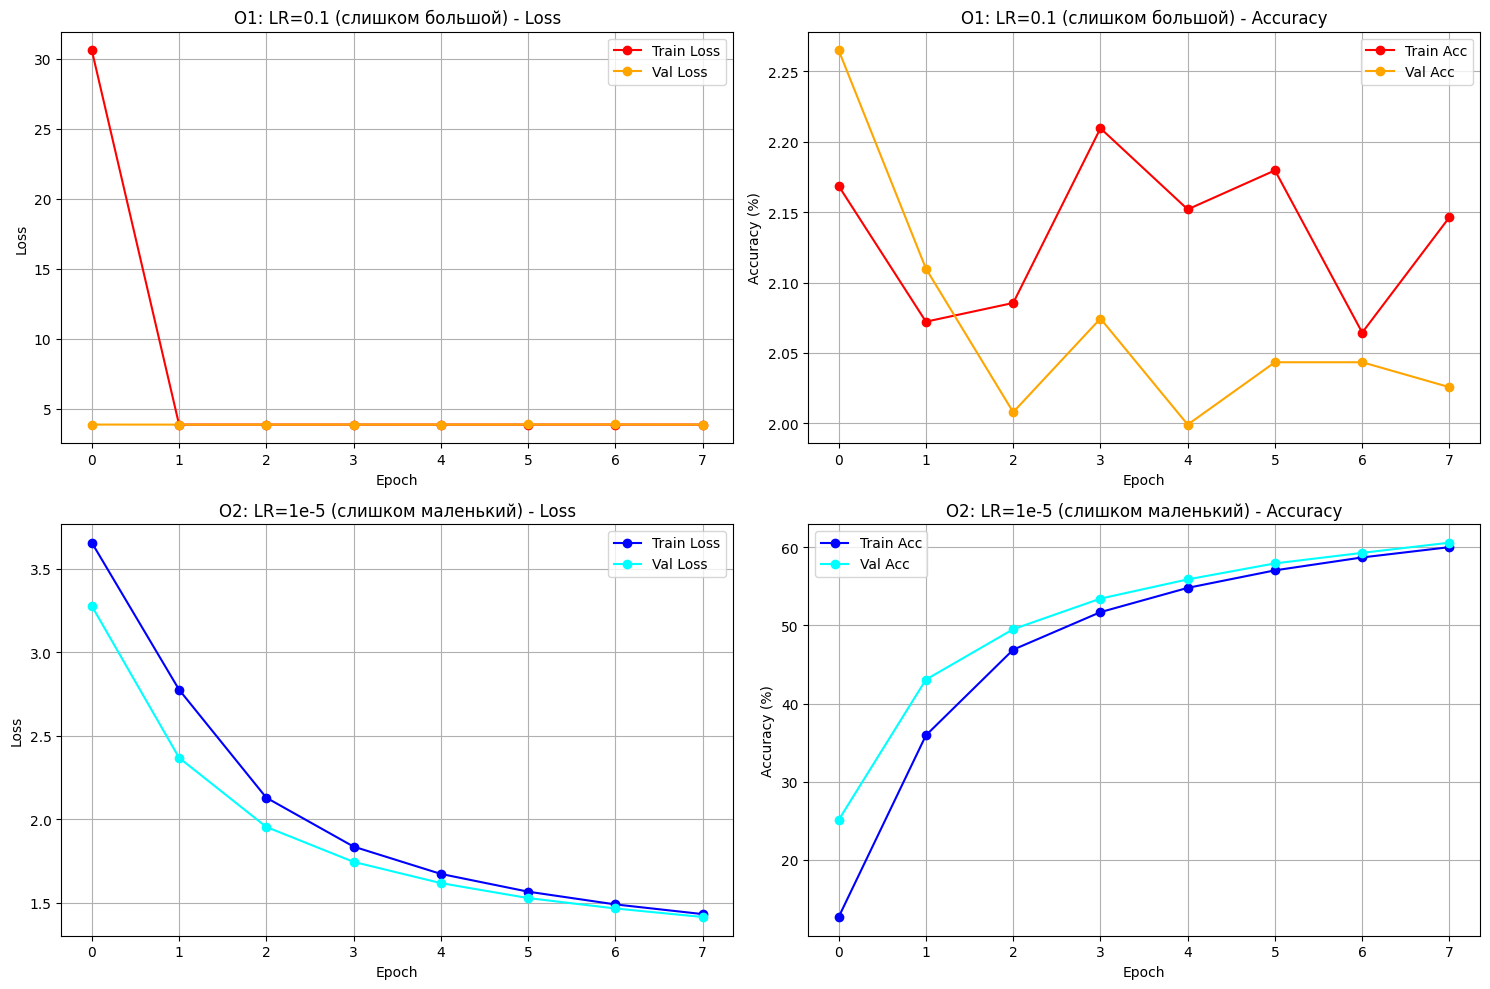

In [14]:
print("ВИЗУАЛИЗАЦИЯ ЭКСТРЕМАЛЬНЫХ LR (O1 и O2)")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# O1 - Loss
axes[0, 0].plot(history_o1['train_loss'], label='Train Loss', marker='o', color='red')
axes[0, 0].plot(history_o1['val_loss'], label='Val Loss', marker='o', color='orange')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('O1: LR=0.1 (слишком большой) - Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# O1 - Accuracy
axes[0, 1].plot(history_o1['train_acc'], label='Train Acc', marker='o', color='red')
axes[0, 1].plot(history_o1['val_acc'], label='Val Acc', marker='o', color='orange')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('O1: LR=0.1 (слишком большой) - Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# O2 - Loss
axes[1, 0].plot(history_o2['train_loss'], label='Train Loss', marker='o', color='blue')
axes[1, 0].plot(history_o2['val_loss'], label='Val Loss', marker='o', color='cyan')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('O2: LR=1e-5 (слишком маленький) - Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# O2 - Accuracy
axes[1, 1].plot(history_o2['train_acc'], label='Train Acc', marker='o', color='blue')
axes[1, 1].plot(history_o2['val_acc'], label='Val Acc', marker='o', color='cyan')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('O2: LR=1e-5 (слишком маленький) - Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150, bbox_inches='tight')
plt.show()

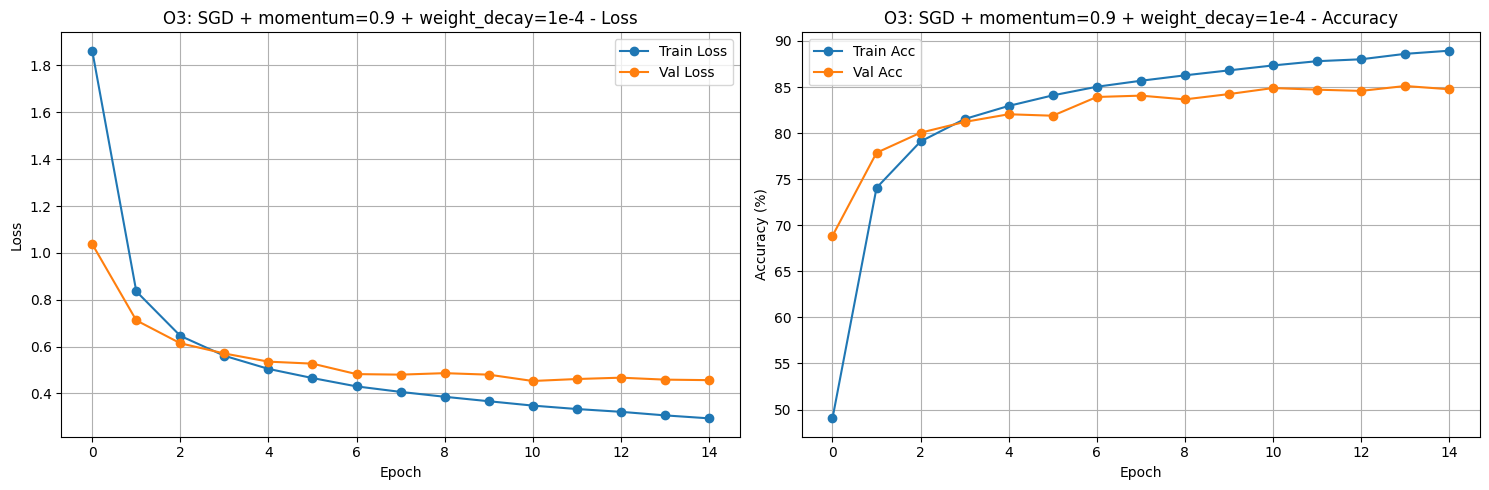

In [15]:
plot_training_history(
    history_o3,
    'O3: SGD + momentum=0.9 + weight_decay=1e-4',
    save_path='artifacts/figures/curves_o3.png'
)

In [16]:
results_df.to_csv('artifacts/runs.csv', index=False)
print("Результаты сохранены в artifacts/runs.csv")
print("\nИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print(results_df.to_string(index=False))

print("\nЛучшая точность на валидации:")
best_val = results_df.loc[results_df['best_val_accuracy'].idxmax()]
print(f"  {best_val['experiment_id']}: {best_val['best_val_accuracy']:.2f}%")

print("\nСравнение E1-E3:")
e1_e3 = results_df[results_df['experiment_id'].isin(['E1', 'E2', 'E3'])]
for _, row in e1_e3.iterrows():
    print(f"  {row['experiment_id']}: {row['best_val_accuracy']:.2f}%")

print(f"\nE4 (Early Stopping): {best_val_acc_e4:.2f}%")
print(f"Test Accuracy лучшей модели: {test_acc:.2f}%")

Результаты сохранены в artifacts/runs.csv

ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:
experiment_id dataset  seed                                        model_summary optimizer      lr  momentum  weight_decay  epochs_trained  best_val_accuracy  best_val_loss
           E1  EMNIST    42 layers=[512, 256, 128], dropout=0.0, batchnorm=False      Adam 0.00100       0.0        0.0000              15            84.7340         0.5187
           E2  EMNIST    42 layers=[512, 256, 128], dropout=0.3, batchnorm=False      Adam 0.00100       0.0        0.0000              15            83.8387         0.4844
           E3  EMNIST    42  layers=[512, 256, 128], dropout=0.0, batchnorm=True      Adam 0.00100       0.0        0.0000              15            85.5230         0.5053
           E4  EMNIST    42  layers=[512, 256, 128], dropout=0.0, batchnorm=True      Adam 0.00100       0.0        0.0000              15            85.6826         0.5101
           O1  EMNIST    42 layers=[512, 256, 128], dropout=0.